# Stock Return Predictor
Predicting next-day AAPL log returns using technical indicators and machine learning.

In [316]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use("dark_background")

In [317]:
df = yf.download('AAPL', start='2018-01-01', end='2024-01-01')
prices = df['Close']['AAPL']
prices.to_csv('../data/aapl_prices.csv')
print(prices.head())
print(prices.shape)

[*********************100%***********************]  1 of 1 completed

Date
2018-01-02    40.267067
2018-01-03    40.260059
2018-01-04    40.447075
2018-01-05    40.907574
2018-01-08    40.755634
Name: AAPL, dtype: float64
(1509,)


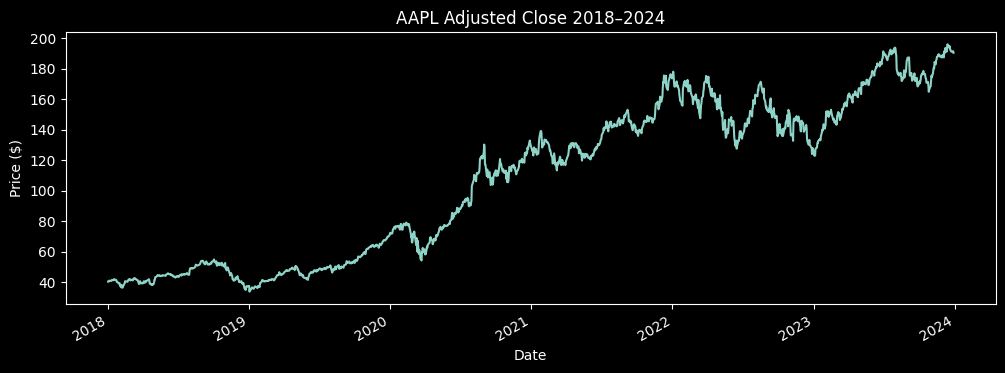

In [318]:
prices.plot(figsize=(12, 4), title='AAPL Adjusted Close 2018–2024')
plt.ylabel('Price ($)')
plt.show()

In [319]:
returns = np.log(prices / prices.shift(1)).dropna()
target = returns.shift(-1).dropna()
returns = returns[returns.index.isin(target.index)]
print(returns.shape, target.shape)

(1507,) (1507,)


In [320]:
features.to_csv('../data/features.csv')
target.to_csv('../data/target.csv')
returns.to_frame().to_csv('../data/returns.csv')

In [321]:
print(f"Returns shape: {returns.shape}")
print(f"Target shape: {target.shape}")
print(f"Any NaN in returns: {returns.isna().any()}")
print(f"Any NaN in target: {target.isna().any()}")
print(f"\nFirst 5 returns:\n{returns.head()}")
print(f"\nFirst 5 targets:\n{target.head()}")

Returns shape: (1507,)
Target shape: (1507,)
Any NaN in returns: False
Any NaN in target: False

First 5 returns:
Date
2018-01-03   -0.000174
2018-01-04    0.004634
2018-01-05    0.011321
2018-01-08   -0.003721
2018-01-09   -0.000115
Name: AAPL, dtype: float64

First 5 targets:
Date
2018-01-03    0.004634
2018-01-04    0.011321
2018-01-05   -0.003721
2018-01-08   -0.000115
2018-01-09   -0.000230
Name: AAPL, dtype: float64


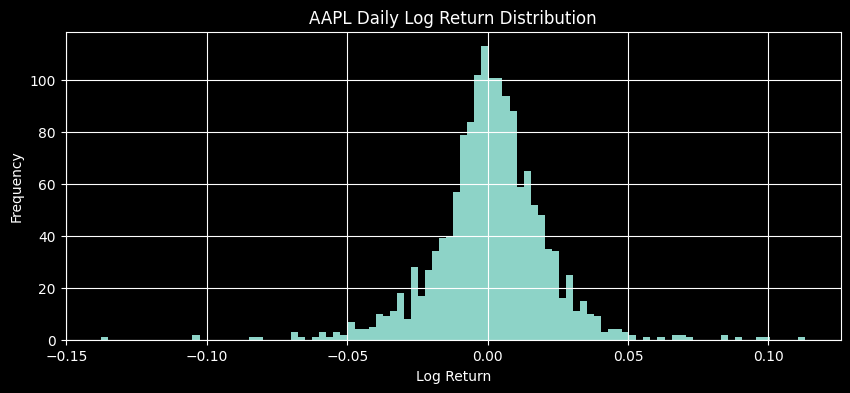

In [322]:
returns.hist(bins=100, figsize=(10, 4))
plt.title('AAPL Daily Log Return Distribution')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()